<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_kampiler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

# Использование kanpiler для встраивания известной формулы

**Задача:** проверить, можно ли получить компактную линейную формулу, если точный вид закона a=−(k/m)x−(c/m)v заранее известен и встроен в архитектуру KAN с помощью инструмента kanpiler.

**Метод:** с помощью kanpiler (компилятора символьных выражений) заданная формула преобразуется в KAN‑сеть с пятью входами (x, v, k, c, m). Сеть обучается оптимизатором Adam (700 шагов) на 6000 точках, после чего применяется автоматическая символьная регрессия с библиотекой ['x'] для получения аналитического выражения.

**Результат:** MSE на тесте составила 5.6е−03, однако символьная регрессия выдала громоздкое нелинейное выражение с дробями и экспонентами, не упростив формулу до ожидаемого линейного вида. Этот эксперимент показывает, что даже при встраивании точного закона в архитектуру автоматическая символьная регрессия не гарантирует компактную интерпретируемую запись, и для её получения могут потребоваться дополнительные шаги (обрезка, дообучение, ограничение библиотеки).

# **Установка библиотек**

In [ ]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-73ex7vv2
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-73ex7vv2
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
  Created wheel for pykan: filename=pykan-0.2.8-py3-none-any.whl size=78235 sha256=155ac285d3afe8e53b00f6621c45e326eaea40de2590c8ed40dc09e27d086ea2
  Stored in directory: /tmp/pip-ephem-wheel-cache-sewwnfph/wheels/e5/c9/d6/a9b7aad8b3f7e1dde415462c7dd48df332ec616b149d51bcb8
Successfully built pykan
Работает на устройстве: cpu


# **Обучение KAN**

In [ ]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []

for k in [2.0, 4.0, 6.0]:
  for c in [0.1, 0.3, 0.5]:
    for m in [0.5, 1.0, 2.0]:

      for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
        for v0 in [0.0, 0.5, 1.0]:

          sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 10, 100))
          x, v = sol.y
          a_clean = -(k/m)*x - (c/m)*v # истинное ускорение

          for i in range(len(x)):
            all_data.append([c, v[i], k, x[i], m, a_clean[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

X = all_data[:, :5]   # (x, v, k, c, m)
y = all_data[:, 5]    # a

# Разбиение на train/test (исходное)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование только x и v (обучаем scaler на трейне, применяем ко всем)
from sklearn.preprocessing import StandardScaler
scaler_dyn = StandardScaler()
scaler_dyn.fit(X_train[:, :2])
X_train[:, :2] = scaler_dyn.transform(X_train[:, :2])
X_test[:, :2]  = scaler_dyn.transform(X_test[:, :2])

# Подвыборки
n_train = 6000
indices_train = np.random.choice(len(X_train), size=n_train, replace=False)
X_train_sub = X_train[indices_train]
y_train_sub = y_train[indices_train]

n_test = 1500
indices_test = np.random.choice(len(X_test), size=n_test, replace=False)
X_test_sub = X_test[indices_test]
y_test_sub = y_test[indices_test]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")

Всего точек: 40500
train: 6000 примеров, test: 1500 примеров


In [ ]:
from kan.compiler import kanpiler
from sympy import symbols, exp, sin, pi
from kan.utils import create_dataset
import torch

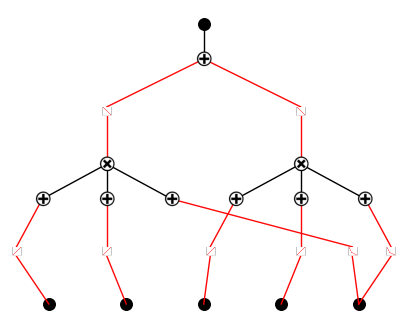

In [ ]:
# Определение символьных переменных и формулуы
x, v, k, c, m = symbols('x, v, k, c, m')
expr = -(k/m)*x-(c/m)*v

# Компиляция
model_kan = kanpiler(input_variables=[c, v, k, x, m], expr=expr)

model_kan.get_act(dataset)
model_kan.plot()

| train_loss: 5.84e-03 | test_loss: 5.62e-03 | reg: 0.00e+00 | : 100%|█| 1200/1200 [01:41<00:00, 11.


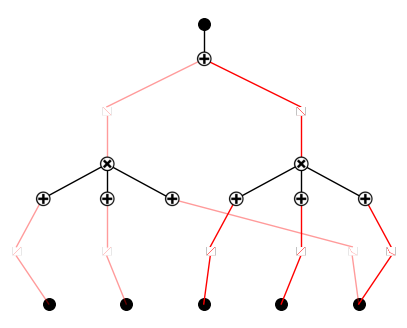

In [ ]:
model_kan.fit(dataset, opt="Adam", steps=700, lr=0.01)
model_kan.plot()

In [ ]:
lib = ['x']
model_kan.auto_symbolic(lib=lib)
formula = ex_round(model_kan.symbolic_formula()[0][0],4)
print("Символьная формула KAN: ", formula)

skipping (0,0,0) since already symbolic
skipping (0,0,1) since already symbolic
skipping (0,0,2) since already symbolic
skipping (0,0,3) since already symbolic
skipping (0,0,4) since already symbolic
skipping (0,0,5) since already symbolic
skipping (0,1,0) since already symbolic
skipping (0,1,1) since already symbolic
skipping (0,1,2) since already symbolic
skipping (0,1,3) since already symbolic
skipping (0,1,4) since already symbolic
skipping (0,1,5) since already symbolic
skipping (0,2,0) since already symbolic
skipping (0,2,1) since already symbolic
skipping (0,2,2) since already symbolic
skipping (0,2,3) since already symbolic
skipping (0,2,4) since already symbolic
skipping (0,2,5) since already symbolic
skipping (0,3,0) since already symbolic
skipping (0,3,1) since already symbolic
skipping (0,3,2) since already symbolic
skipping (0,3,3) since already symbolic
skipping (0,3,4) since already symbolic
skipping (0,3,5) since already symbolic
skipping (0,4,0) since already symbolic
